In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
from misc import fishinv

try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

startup


[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 788953) PSD_funcs: (3, 394476)
[TRUE] SNR: 95.307243
[TRUE] SNR - Channel 0: 47.962480
[TRUE] SNR - Channel 1: 82.359363
[TRUE] SNR - Channel 2: 0.079973
[INFO] Frequency resolution delta_f: 1.267503e-07 Hz, Number of frequency bins: 394477
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz


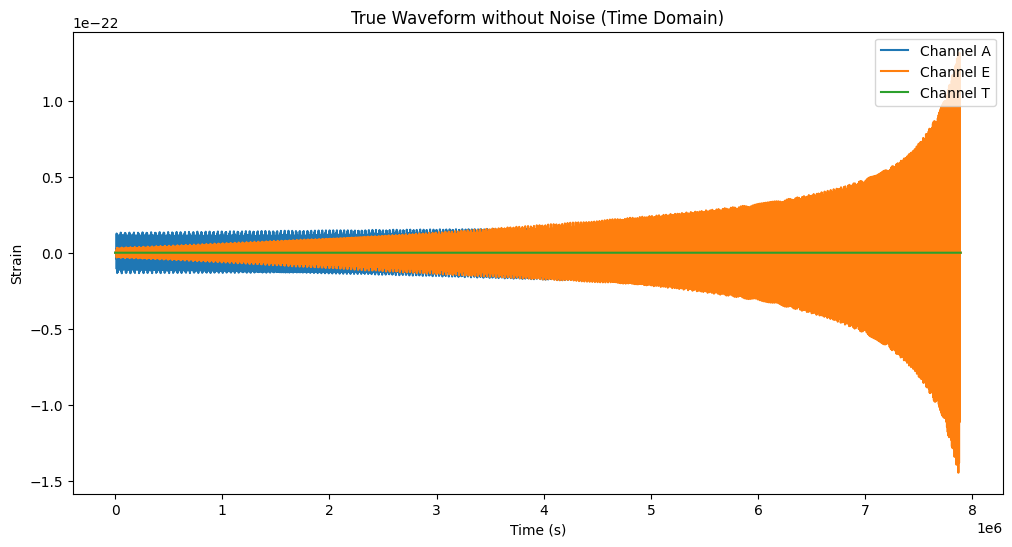

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 394476)


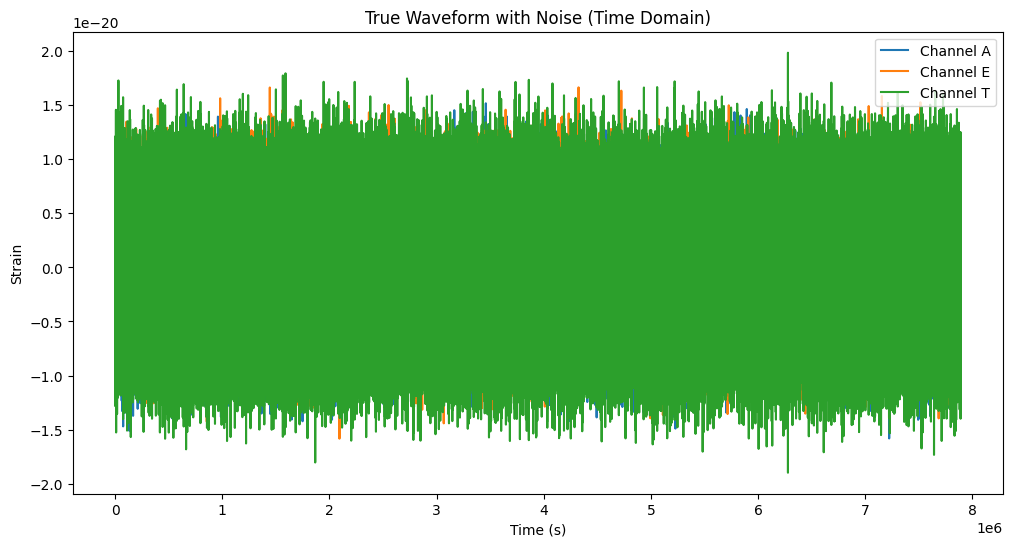

Length of PSD: 394476


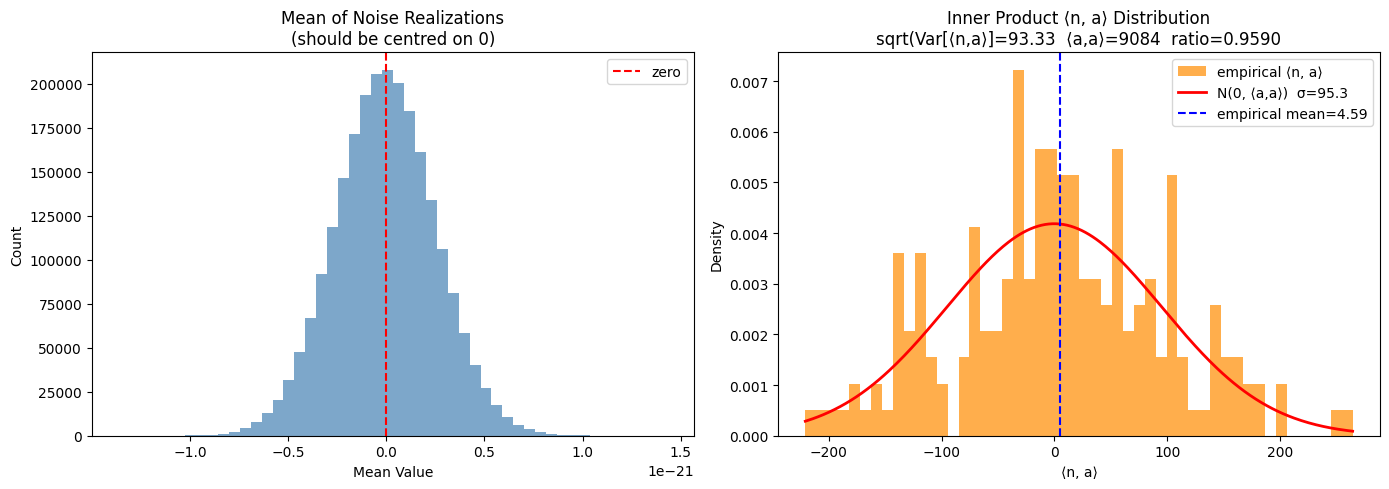

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 200
  N time samples         : 788950  |  PSD bins passed: 394475
  N (template samples)   : 788953  →  aligned to 788950
  Max |mean noise|       : 1.4279e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : 4.5909e+00           (expect ≈ 0)
  Var[⟨n, a⟩]           : 8710.77
  ⟨a, a⟩                : 9083.64
  Ratio Var/⟨a,a⟩       : 0.958952          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[ 2.48360296e-22, -1.35048831e-22,  1.07962550e-22, ...,
         3.82699322e-22, -2.40724836e-22,  5.42400267e-23],
       [-2.47328944e-22,  2.22439633e-22, -6.31564758e-24, ...,
        -4.54754517e-22,  7.98487013e-23, -1.09507270e-22],
       [ 2.62495603e-22, -2.53760104e-22,  2.61489531e-22, ...,
        -1.14390643e-22,  8.89550111e-23, -9.29492933e-23]],
      shape=(3, 788950)), 'inner_products': array([  21.2413129 ,  -75.95018625,   99.36699227,   -5.69198828,
         5

{'m1': np.float64(1000000.0),
 'm2': np.float64(5000.0),
 'a': np.float64(0.7),
 'p0': np.float64(25.0),
 'e0': np.float64(0.25),
 'Y0': np.float64(1.0),
 'dist': np.float64(12.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 10,
 'T': 0.25,
 'chi2': 0.95,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1554c8066d80>,
 'PSD_funcs': array([[4.26101649e-36, 1.06525447e-36, 4.73446683e-37, ...,
         1.61317874e-40, 1.61314534e-40, 1.61311193e-40],
        [4.26101649e-36, 1.06525447e-36, 4.73446683e-37, ...,
         1.61317874e-40, 1.61314534e-40, 1.61311193e-40],
        [4.25581070e-55, 1.70232428e-54, 3.83022963e-54, ...,
         5.36087803e-40, 5.36079136e-40, 5.36070468e-40]],
       shape=(3, 394476)),
 'waveform_true_fft': array([[-7.82112057e-16

In [2]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

#last used
# signal_param = {
#     "m1": 1e6,
#     "m2": 5.00000000e+03,
#     "a": 0.70,
#     "p0": 25.0,
#     "e0": 0.25,
#     "xI0": 1.0,
#     "dist": 10,
#     "qS": np.pi/4,
#     "phiS": 1,
#     "qK": 1,
#     "phiK": np.pi/3,
#     "Phi_phi0": 0.9,
#     "Phi_theta0": 0.5,
#     "Phi_r0": 4.0000e-01,
# }
signal_param = {
    "m1": 1e6,
    "m2": 5.00000000e+03,
    "a": 0.70,
    "p0": 25.0,
    "e0": 0.25,
    "xI0": 1.0,
    "dist": 12,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.0000e-01,
}

signal_param_array = np.array(list(signal_param.values()))
dt = 10  #Time step for waveform generation; default 0.1s
T= 0.25

chi2 = 0.95 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

In [3]:
noise_f =  ctx['noise']
Respsone = ctx['waveform_response']

In [4]:
use_gpu = True
channels = [A1TDISens, E1TDISens, T1TDISens]
noise_kwargs = [{"sens_fn": ch} for ch in channels]

sef = StableEMRIFisher(waveform_class=SuperKludgeWaveform,
                       waveform_class_kwargs = dict(sum_kwargs=dict(pad_output=False, odd_len=True)),
                       waveform_generator = GenerateEMRIWaveform,
                       waveform_generator_kwargs= dict(return_list=False),
                       ResponseWrapper=ResponseWrapper,
                       ResponseWrapper_kwargs = dict(Tobs=ctx['T'],
                                                    t0=10000.0,
                                                    dt=ctx['dt'],
                                                    index_lambda=8,
                                                    index_beta=7,
                                                    flip_hx=True,
                                                    is_ecliptic_latitude=False,
                                                    remove_garbage="zero",
                                                    orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
                                                    force_backend = "cuda12x" if use_gpu else "cpu",
                                                    order=20,
                                                    tdi="1st generation",
                                                    tdi_chan="AET"),
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs=noise_kwargs,
                       channels=channels,
                       T = ctx['T'], dt = ctx['dt'],
                       stability_plot = False,
                       der_order = 6, Ndelta = 12,
                       plunge_check=True, return_derivatives=False
                       )
emri_kwargs = {"T":ctx['T'], "dt":ctx['dt']}



waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1000000.6157287196, 4999.999391375213, 0.7000474012600719, 24.99994304374421, 0.2500081838875367, np.float64(1.0), np.float64(12.0), 0.7877861127640066, 1.001873110230141, np.float64(1.0), np.float64(1.0471975511965976), 0.9207595116762446, np.float64(0.5), 0.39466840656966434, 0.95, True, False, False, True, 0, 0)
SNR:  95.58025096041943
Body is not plunging, Fisher should be stable.
waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1000000.6157287196, 4999.999391375213, 0.7000474012600719, 24.99994304374421, 0.2500081838875367, np.float64(1.0), np.float64(12.0), 0.7877861127640066, 1.001873110230141, np.float64(1.0), np.float64(1.0471975511965976), 0.9207595116762446, np.float64(0.5), 0.39466840656966434, 0.95, True, False, False, True, 0, 0)
Waveform Generated. SNR: 95.58025096041943
calculating stable deltas...
Gamma_ii for m1: 78.9235372719207
Gamma_ii for m1: 78.92353856667661
Gamma_ii f

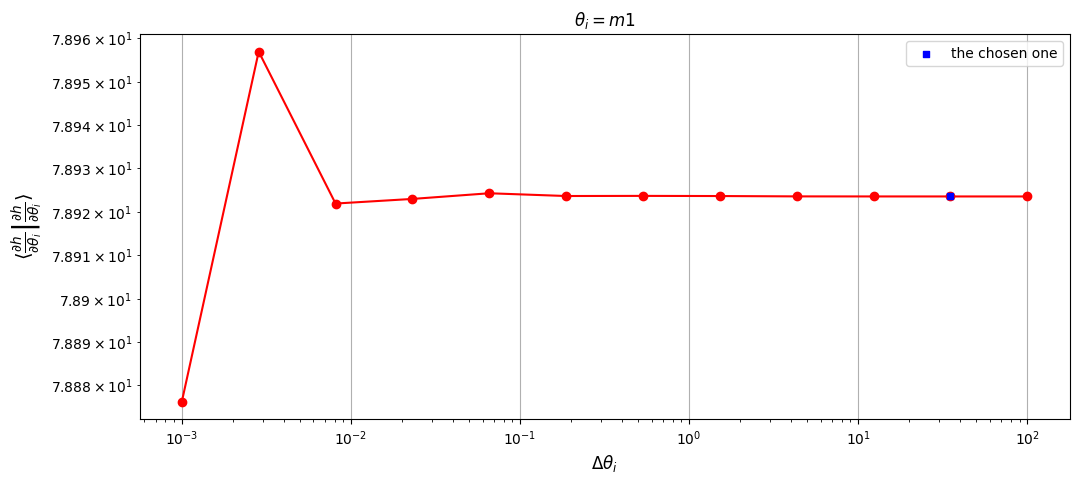

Gamma_ii for m2: 330878.5786740311
Gamma_ii for m2: 330878.43598381104
Gamma_ii for m2: 330878.5142251713
Gamma_ii for m2: 330878.53727376397
Gamma_ii for m2: 330877.70938748214
Gamma_ii for m2: 330878.2261651317
Gamma_ii for m2: 330889.42302204296
Gamma_ii for m2: 330906.64502033463
Gamma_ii for m2: 330857.44113437657
Gamma_ii for m2: 330846.5016056739
Gamma_ii for m2: 331299.24062603526
Gamma_ii for m2: 330269.5068928953
[np.float64(4.3124665893851134e-07), np.float64(2.3646552101033209e-07), np.float64(6.965877225841003e-08), np.float64(2.502091432386435e-06), np.float64(1.561836375785352e-06), np.float64(3.383866673335778e-05), np.float64(5.204488501768798e-05), np.float64(0.00014871627426411838), np.float64(3.30652693909405e-05), np.float64(0.0013665561668835095), np.float64(0.003117858935350848)]
2


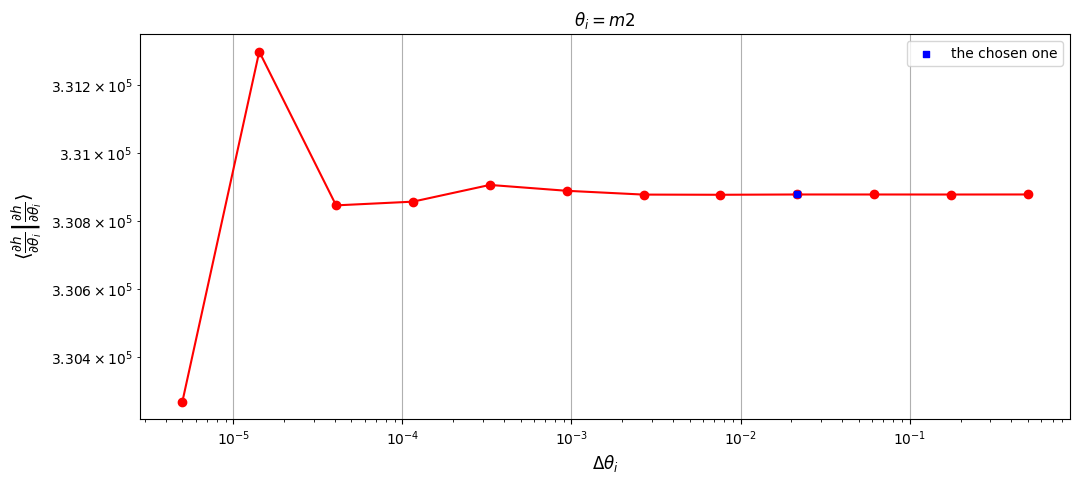

Gamma_ii for a: 178339118253.5955
Gamma_ii for a: 178339053217.7393
Gamma_ii for a: 178339597238.31793
Gamma_ii for a: 178338865274.24384
Gamma_ii for a: 178338726211.1137
Gamma_ii for a: 178336239865.5466
Gamma_ii for a: 178342755121.95074
Gamma_ii for a: 178319677706.8961
Gamma_ii for a: 178506329932.64734
Gamma_ii for a: 180475670558.3987
Gamma_ii for a: 178587056443.73257
Gamma_ii for a: 179763278322.96487
[np.float64(3.646753474785342e-07), np.float64(3.0504755369432386e-06), np.float64(4.104344125836444e-06), np.float64(7.797696724733418e-07), np.float64(1.3941897445985682e-05), np.float64(3.6532217973694285e-05), np.float64(0.0001294159755749969), np.float64(0.0010456336524406582), np.float64(0.010911945192712996), np.float64(0.010575313532093426), np.float64(0.006543171053651377)]
0


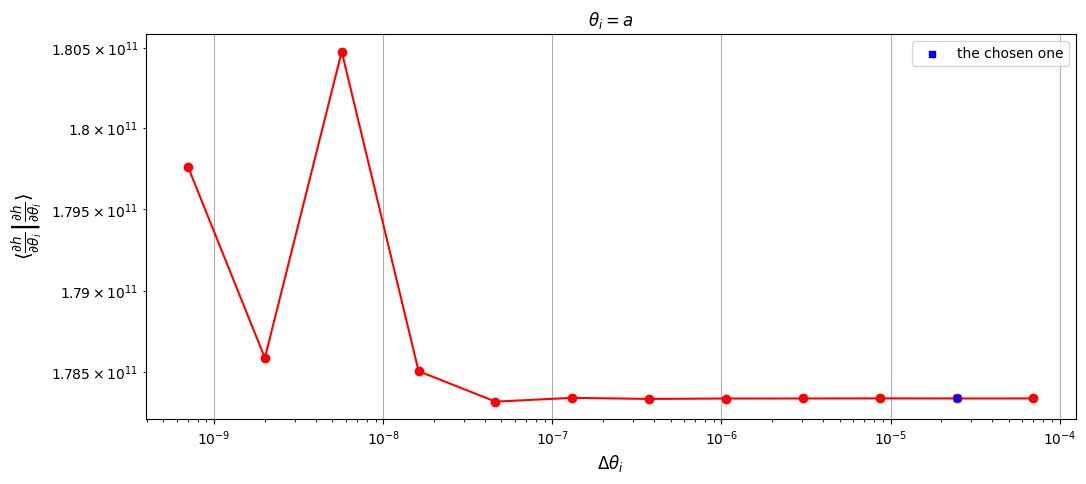

Gamma_ii for p0: 419405432563.119
Gamma_ii for p0: 419405442593.63916
Gamma_ii for p0: 419405483665.20605
Gamma_ii for p0: 419405340156.48016
Gamma_ii for p0: 419405340120.50726
Gamma_ii for p0: 419405064062.7036
Gamma_ii for p0: 419406357876.61566
Gamma_ii for p0: 419402216536.10284
Gamma_ii for p0: 419403245317.01074
Gamma_ii for p0: 419414016883.3805
Gamma_ii for p0: 419373767893.8832
Gamma_ii for p0: 419136074884.8388
[np.float64(2.391604667686706e-08), np.float64(9.792806363809246e-08), np.float64(3.4217190901186464e-07), np.float64(8.577120258003617e-11), np.float64(6.582128526913304e-07), np.float64(3.0848695727902255e-06), np.float64(9.874388712156197e-06), np.float64(2.452963631982231e-06), np.float64(2.5682418651129743e-05), np.float64(9.597402741579896e-05), np.float64(0.0005671022450398257)]
3


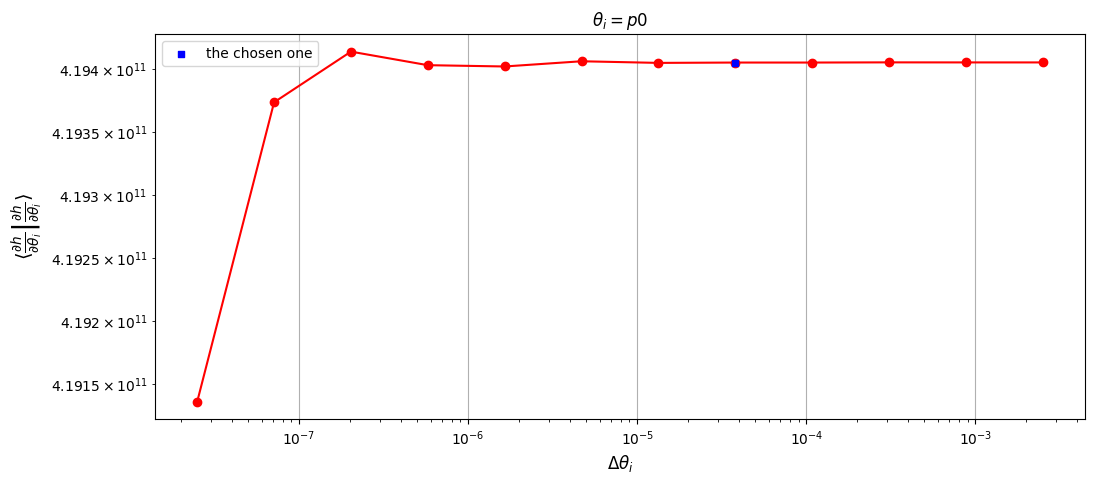

Gamma_ii for e0: 3555532108838.179
Gamma_ii for e0: 3555533089641.2085
Gamma_ii for e0: 3555533067439.542
Gamma_ii for e0: 3555525992178.31
Gamma_ii for e0: 3555536012391.164
Gamma_ii for e0: 3555388710477.888
Gamma_ii for e0: 3555116293897.0356
Gamma_ii for e0: 3556033437785.4634
Gamma_ii for e0: 3558566821708.892
Gamma_ii for e0: 3550362424263.4844
Gamma_ii for e0: 3555052850042.0435
Gamma_ii for e0: 3483645904219.593
[np.float64(2.75852594974963e-07), np.float64(6.2442581977994125e-09), np.float64(1.9899337671833195e-06), np.float64(2.8182003554690836e-06), np.float64(4.143060724746457e-05), np.float64(7.662662999806467e-05), np.float64(0.000257912054111305), np.float64(0.0007119112975408823), np.float64(0.0023108619529482828), np.float64(0.0013193687903974793), np.float64(0.02049776234029942)]
1


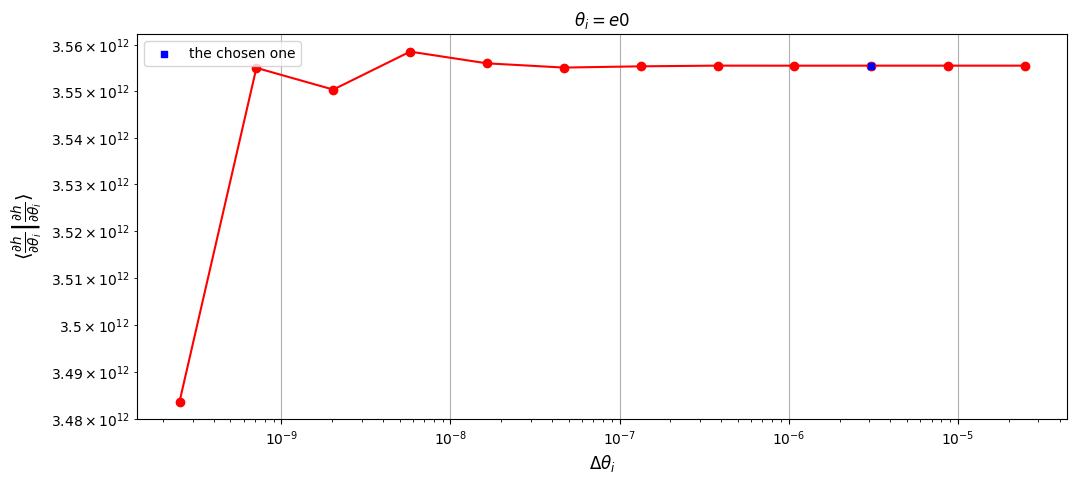

Gamma_ii for qS: 197193.35201701807
Gamma_ii for qS: 227705.0275855129
Gamma_ii for qS: 227191.3890816098
Gamma_ii for qS: 227211.38812993804
Gamma_ii for qS: 227151.68568662286
Gamma_ii for qS: 227153.41830490204
Gamma_ii for qS: 227164.8888537423
Gamma_ii for qS: 227507.2659640781
Gamma_ii for qS: 232262.93672891616
Gamma_ii for qS: 256831.8810633458
Gamma_ii for qS: 582789.6837832691
Gamma_ii for qS: 333618.7393567902
[np.float64(0.13399649490407672), np.float64(0.0022608185370906887), np.float64(8.801956844167409e-05), np.float64(0.0002628307297597915), np.float64(7.62752456952856e-06), np.float64(5.0494373924369707e-05), np.float64(0.0015049062669930742), np.float64(0.0204753751580632), np.float64(0.09566158310529163), np.float64(0.5593060615004678), np.float64(0.7468733468236083)]
4


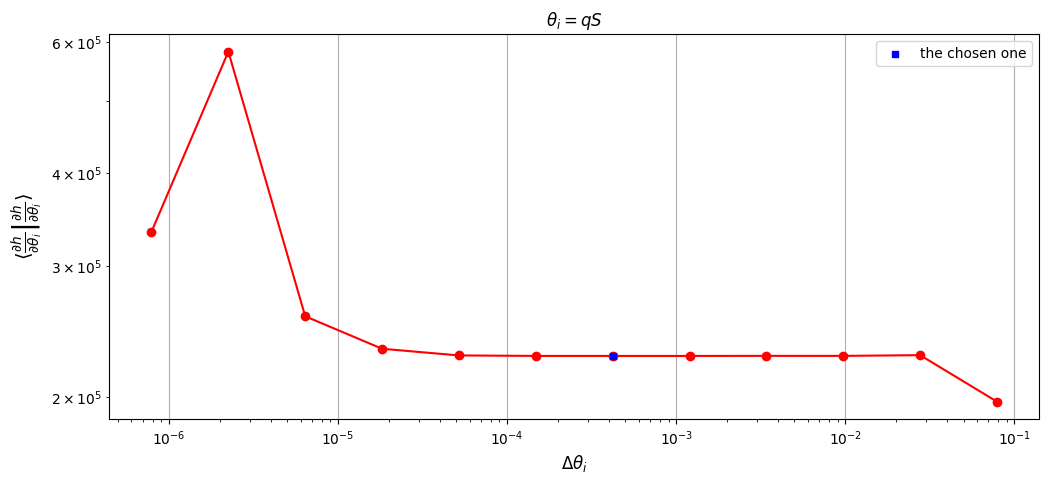

Gamma_ii for phiS: 316648.0446862006
Gamma_ii for phiS: 326523.78911194525
Gamma_ii for phiS: 326598.5610501275
Gamma_ii for phiS: 326598.31064314494
Gamma_ii for phiS: 326606.5213862802
Gamma_ii for phiS: 326596.5625488528
Gamma_ii for phiS: 326622.5642698492
Gamma_ii for phiS: 326760.6315799419
Gamma_ii for phiS: 329329.9417526595
Gamma_ii for phiS: 346202.0493625149
Gamma_ii for phiS: 341378.9605020419
Gamma_ii for phiS: 361849.0040607369
[np.float64(0.030245099300739885), np.float64(0.00022894141952683832), np.float64(7.667124243805403e-07), np.float64(2.5139556615092397e-05), np.float64(3.0492780908812694e-05), np.float64(7.960785273523488e-05), np.float64(0.0004225334901120166), np.float64(0.007801629451133447), np.float64(0.04873485769631683), np.float64(0.01412825457485733), np.float64(0.056570678180612254)]
2


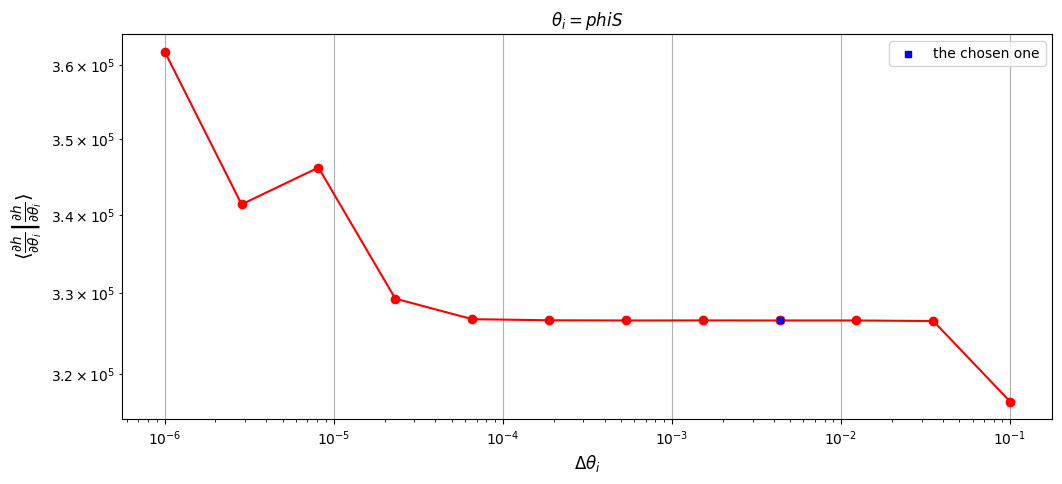

stable deltas: {'m1': 35.111938961567205, 'm2': 0.02164380377082388, 'a': 2.4580006488631493e-05, 'p0': 3.799769050537891e-05, 'e0': 3.082217743395822e-06, 'qS': 0.0004204177542342685, 'phiS': 0.004336869528122495, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 25.774755716323853 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 1.9557013511657715 seconds


In [5]:
x_best_fit_1PA =  [1000000.6157287196, 4999.999391375213, 0.7000474012600719, 24.99994304374421, 0.2500081838875367, 0.7877861127640066, 1.001873110230141, 0.9207595116762446, 0.39466840656966434]
add_kwargs_1PA = {'chi2': 0.95,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 0, 'dev_2': 0}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_1PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_1PA['chi2'],add_kwargs_1PA['evolve_1PA'],add_kwargs_1PA['evolve_primary'],
                    add_kwargs_1PA['evolve_2PA'], add_kwargs_1PA['deviation_included'],add_kwargs_1PA['dev_1'],add_kwargs_1PA['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_1PA = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_1PA,
            live_dangerously = False, stability_plot = True,der_order = 6, Ndelta = 12,return_derivatives = False)



waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1001848.4098411817, 4994.378456817518, 0.7041283639326336, 24.96534376604303, 0.24984727959036643, np.float64(1.0), np.float64(12.0), 0.7862258676179033, 1.0080172048538822, np.float64(1.0), np.float64(1.0471975511965976), 0.94380724909814, np.float64(0.5), 0.3753956745465233, 0.95, False, False, False, True, 0, 0)
SNR:  95.59203527055887
Body is not plunging, Fisher should be stable.
waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1001848.4098411817, 4994.378456817518, 0.7041283639326336, 24.96534376604303, 0.24984727959036643, np.float64(1.0), np.float64(12.0), 0.7862258676179033, 1.0080172048538822, np.float64(1.0), np.float64(1.0471975511965976), 0.94380724909814, np.float64(0.5), 0.3753956745465233, 0.95, False, False, False, True, 0, 0)
Waveform Generated. SNR: 95.59203527055887
calculating stable deltas...
Gamma_ii for m1: 78.70302545882683
Gamma_ii for m1: 78.70302621378916
Gamma_ii 

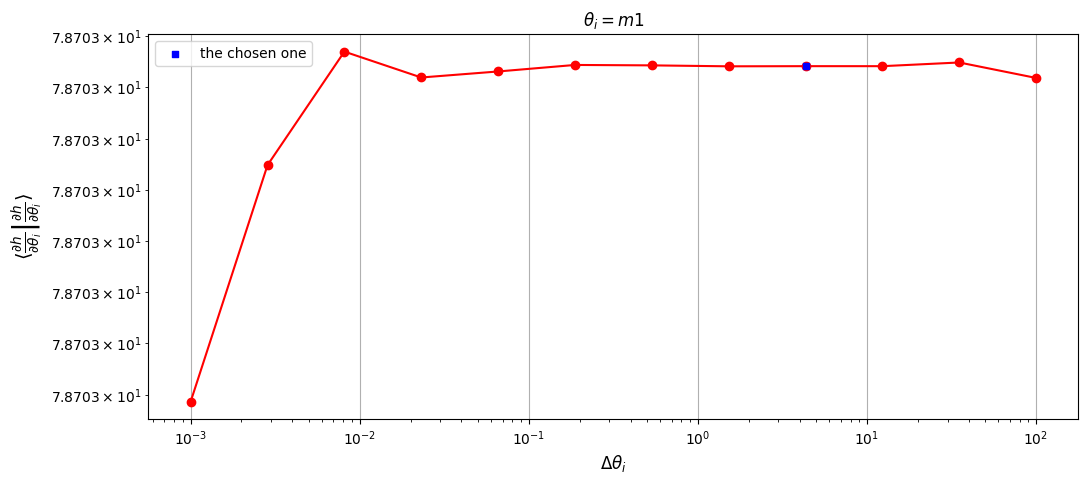

Gamma_ii for m2: 331797.6030438544
Gamma_ii for m2: 331797.6021110186
Gamma_ii for m2: 331797.6021214085
Gamma_ii for m2: 331797.6021167163
Gamma_ii for m2: 331797.60209987307
Gamma_ii for m2: 331797.6020284607
Gamma_ii for m2: 331797.6010596737
Gamma_ii for m2: 331797.60525120964
Gamma_ii for m2: 331797.58770818665
Gamma_ii for m2: 331797.6001863374
Gamma_ii for m2: 331797.66713455
Gamma_ii for m2: 331797.67389459204
[np.float64(2.811460339801134e-09), np.float64(3.1313947972021247e-11), np.float64(1.4141686751084342e-11), np.float64(5.076365740327314e-11), np.float64(2.1522867975358815e-10), np.float64(2.9198131666588545e-09), np.float64(1.2632809478248283e-08), np.float64(5.287266585533589e-08), np.float64(3.760771858982615e-08), np.float64(2.0177421120817223e-07), np.float64(2.0373988656959946e-08)]
2


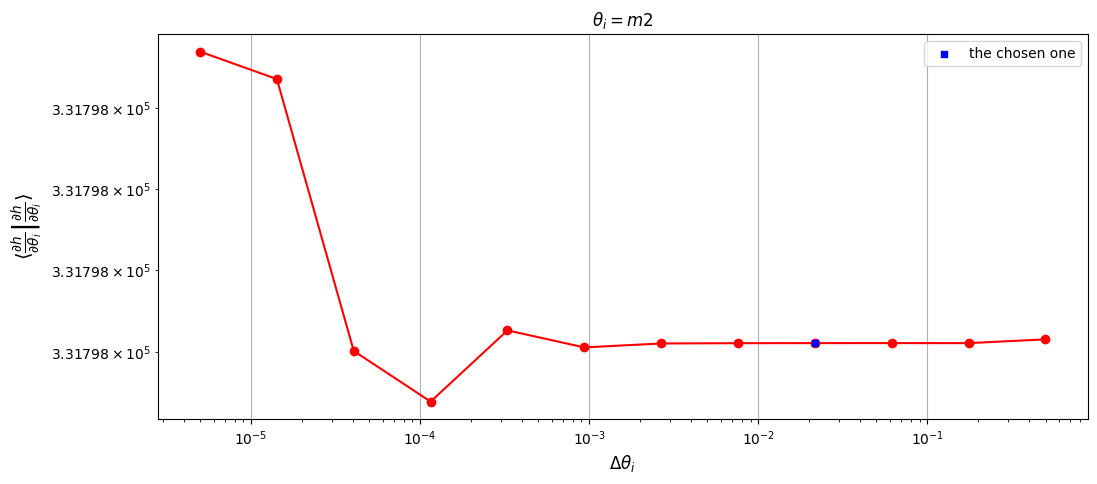

Gamma_ii for a: 152252606456.10992
Gamma_ii for a: 152252696195.3778
Gamma_ii for a: 152251943113.53394
Gamma_ii for a: 152252466538.0897
Gamma_ii for a: 152256230944.45355
Gamma_ii for a: 152249397059.6965
Gamma_ii for a: 152231111855.9527
Gamma_ii for a: 152222264746.62015
Gamma_ii for a: 152649532836.39642
Gamma_ii for a: 151500366410.62918
Gamma_ii for a: 150816982735.2148
Gamma_ii for a: 161751020247.97736
[np.float64(5.89410040845143e-07), np.float64(4.946287242524707e-06), np.float64(3.4378724210991206e-06), np.float64(2.47241530971197e-05), np.float64(4.488612033300872e-05), np.float64(0.00012011476183072971), np.float64(5.811968010905898e-05), np.float64(0.0027990134122074534), np.float64(0.007585238590463353), np.float64(0.0045312116912865534), np.float64(0.0675979508259038)]
0


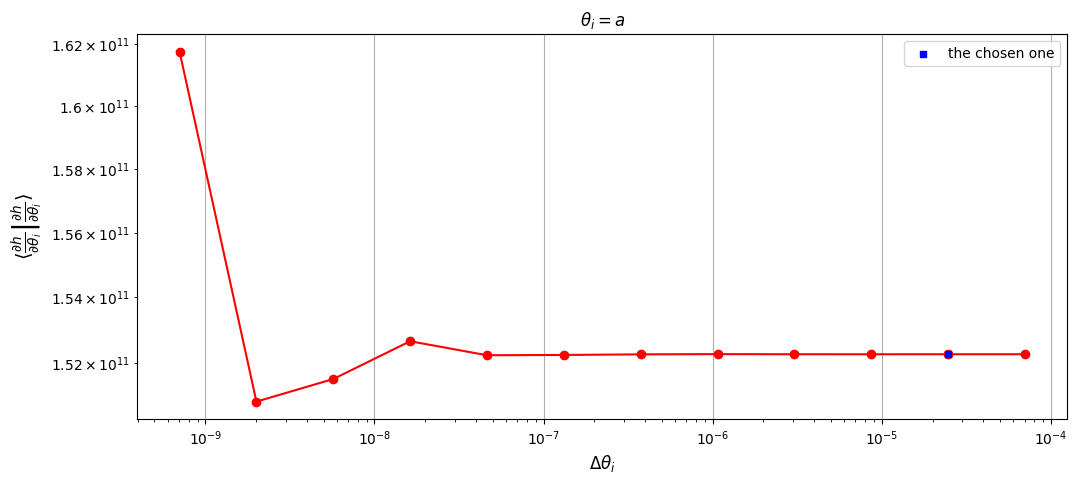

Gamma_ii for p0: 420699366320.2268
Gamma_ii for p0: 420699345790.0712
Gamma_ii for p0: 420699321513.6223
Gamma_ii for p0: 420699305746.84753
Gamma_ii for p0: 420699276893.0084
Gamma_ii for p0: 420699703973.0923
Gamma_ii for p0: 420701348584.79193
Gamma_ii for p0: 420700680605.6553
Gamma_ii for p0: 420690077042.9412
Gamma_ii for p0: 420707293931.82556
Gamma_ii for p0: 420873051948.4003
Gamma_ii for p0: 420718846209.40894
[np.float64(4.8800065376992095e-08), np.float64(5.7704987082533585e-08), np.float64(3.7477539337231446e-08), np.float64(6.858542597083234e-08), np.float64(1.015166114520538e-06), np.float64(3.909214232800412e-06), np.float64(1.5877776467964563e-06), np.float64(2.520516478207294e-05), np.float64(4.0923675754308e-05), np.float64(0.0003938432641562669), np.float64(0.00036652919254926737)]
2


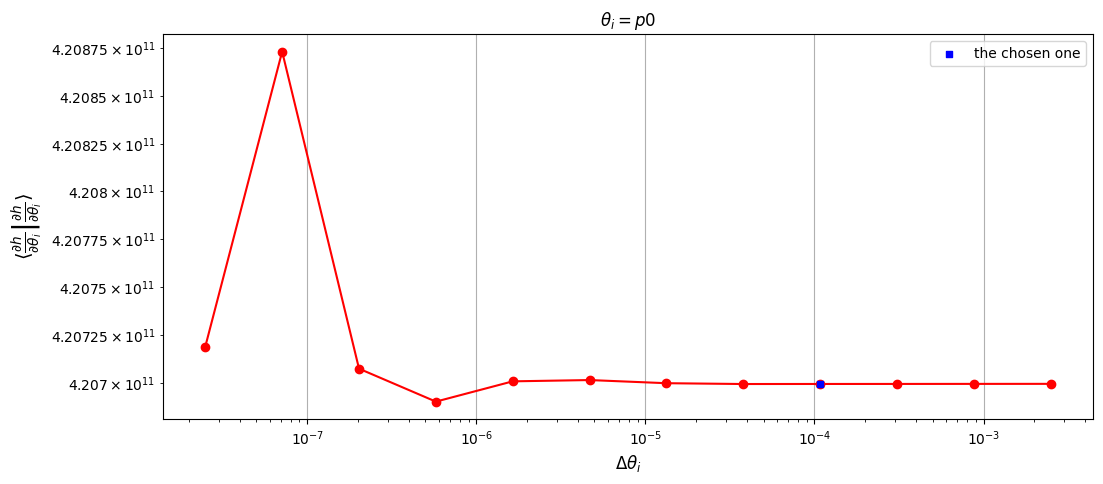

Gamma_ii for e0: 3553744676643.9546
Gamma_ii for e0: 3553742740022.808
Gamma_ii for e0: 3553741635334.493
Gamma_ii for e0: 3553762263309.4663
Gamma_ii for e0: 3553752316309.682
Gamma_ii for e0: 3553850356532.2764
Gamma_ii for e0: 3553666400180.0596
Gamma_ii for e0: 3554277135644.4634
Gamma_ii for e0: 3548330267343.9546
Gamma_ii for e0: 3552375891802.6475
Gamma_ii for e0: 3541352090951.7256
Gamma_ii for e0: 3507892432358.3696
[np.float64(5.449525438839013e-07), np.float64(3.108521744961992e-07), np.float64(5.804545561788532e-06), np.float64(2.799013239760315e-06), np.float64(2.75870429980351e-05), np.float64(5.1765228218235695e-05), np.float64(0.0001718311322094105), np.float64(0.001675962453450034), np.float64(0.0011388503305712744), np.float64(0.0031128790834122535), np.float64(0.00953839356210273)]
1


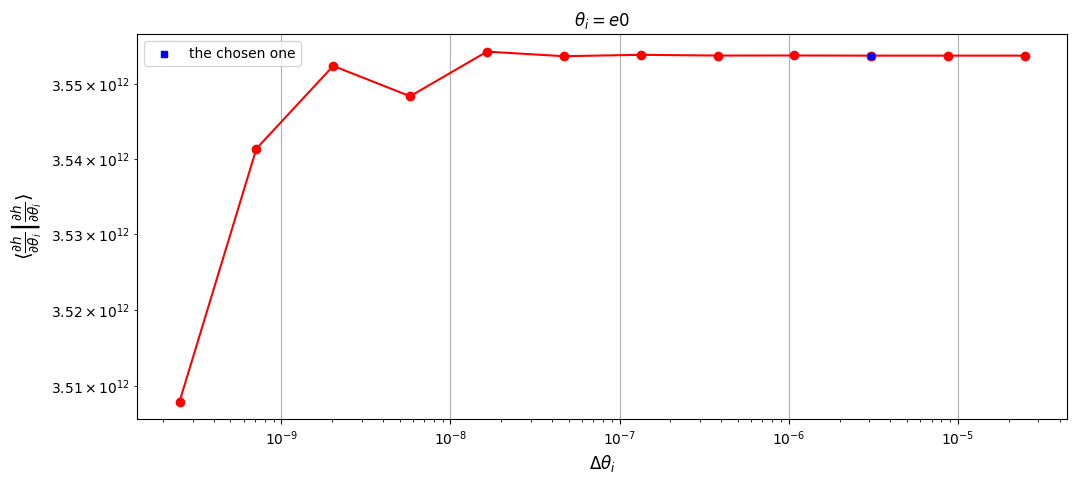

Gamma_ii for qS: 174555.26315909365
Gamma_ii for qS: 209820.06630433773
Gamma_ii for qS: 209297.42696881783
Gamma_ii for qS: 209313.69633998338
Gamma_ii for qS: 209723.44393186664
Gamma_ii for qS: 212871.92537924473
Gamma_ii for qS: 237516.46890365257
Gamma_ii for qS: 435864.4929382405
Gamma_ii for qS: 2042534.4254331922
Gamma_ii for qS: 15092838.159910563
Gamma_ii for qS: 5860146.119833558
Gamma_ii for qS: 253979.43964082882
[np.float64(0.16807164236662445), np.float64(0.0024971130466776427), np.float64(7.772721732991024e-05), np.float64(0.0019537519706970857), np.float64(0.014790496406554637), np.float64(0.1037593040944238), np.float64(0.4550680939791366), np.float64(0.7866060480984061), np.float64(0.8646686326460088), np.float64(1.5755054313115378), np.float64(22.073309115575757)]
2


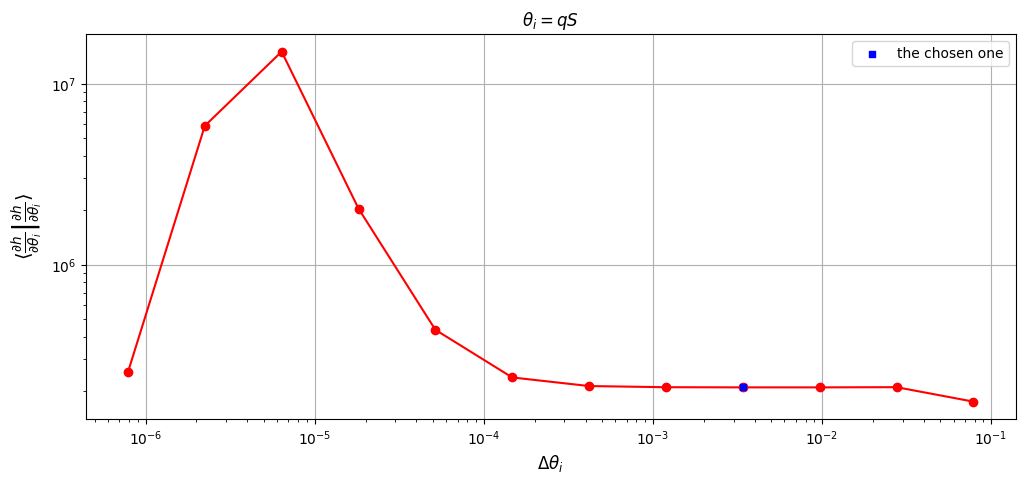

Gamma_ii for phiS: 316486.542656349
Gamma_ii for phiS: 327330.3353975742
Gamma_ii for phiS: 327413.80731480336
Gamma_ii for phiS: 327438.00281953916
Gamma_ii for phiS: 327647.68659440405
Gamma_ii for phiS: 329435.62063152477
Gamma_ii for phiS: 344208.6949703196
Gamma_ii for phiS: 464294.16042734927
Gamma_ii for phiS: 1437946.0071648338
Gamma_ii for phiS: 341445.126770577
Gamma_ii for phiS: 338163.49443269253
Gamma_ii for phiS: 338771.00253782555
[np.float64(0.033127979806864924), np.float64(0.00025494318005020396), np.float64(7.389339211533393e-05), np.float64(0.0006399672069848956), np.float64(0.005427263857178742), np.float64(0.04291894584495797), np.float64(0.25864091279222573), np.float64(0.6771129387933086), np.float64(3.2113531411769576), np.float64(0.009704277344867644), np.float64(0.00179327067718905)]
2


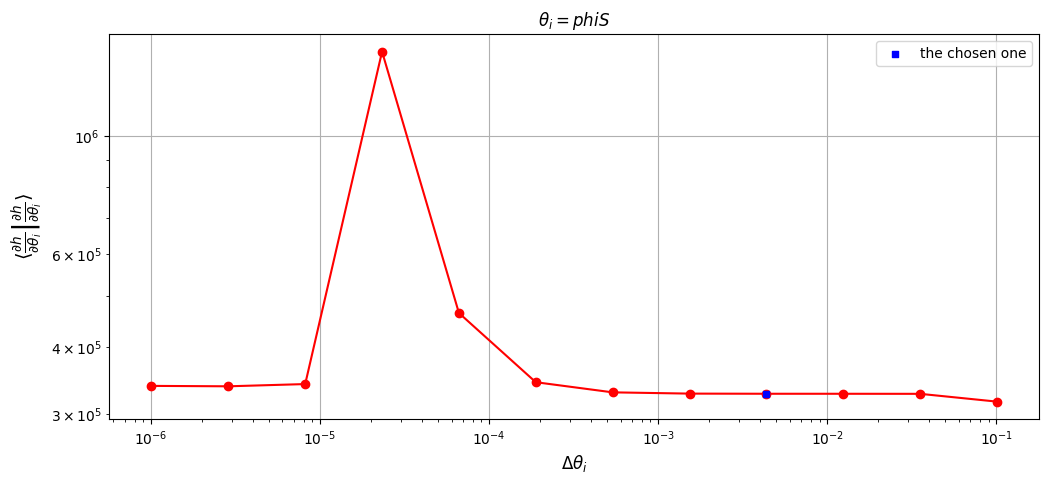

stable deltas: {'m1': 4.3367626060351405, 'm2': 0.02161947208694704, 'a': 2.472329691266686e-05, 'p0': 0.00010806901346337535, 'e0': 3.080234040014537e-06, 'qS': 0.0034033840939303134, 'phiS': 0.004363465847037058, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 22.76629900932312 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 1.7606022357940674 seconds


In [6]:
x_best_fit_0PA =  [1001848.4098411817, 4994.378456817518, 0.7041283639326336, 24.96534376604303, 0.24984727959036643, 0.7862258676179033, 1.0080172048538822, 0.94380724909814, 0.3753956745465233]
add_kwargs_0PA = {'chi2': 0.95,'evolve_1PA': False,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': 0, 'dev_2': 0}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = x_best_fit_0PA
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA['chi2'],add_kwargs_0PA['evolve_1PA'],add_kwargs_0PA['evolve_primary'],
                    add_kwargs_0PA['evolve_2PA'], add_kwargs_0PA['deviation_included'],add_kwargs_0PA['dev_1'],add_kwargs_0PA['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_0PA = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA,
            live_dangerously = False, stability_plot = True,der_order = 6, Ndelta = 12,return_derivatives = False)



waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1002773.5087947377, 4951.996076834916, 0.7054139072521527, 24.953294077033906, 0.24963513535683254, np.float64(1.0), np.float64(12.0), 0.7875895689149237, 1.001918539952816, np.float64(1.0), np.float64(1.0471975511965976), 0.9156601963955119, np.float64(0.5), 0.4109580708321073, 0.95, False, False, False, True, 1.7364060670631016, 2.1384810088591153)
SNR:  94.77789461900134
Body is not plunging, Fisher should be stable.
waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (1002773.5087947377, 4951.996076834916, 0.7054139072521527, 24.953294077033906, 0.24963513535683254, np.float64(1.0), np.float64(12.0), 0.7875895689149237, 1.001918539952816, np.float64(1.0), np.float64(1.0471975511965976), 0.9156601963955119, np.float64(0.5), 0.4109580708321073, 0.95, False, False, False, True, 1.7364060670631016, 2.1384810088591153)
Waveform Generated. SNR: 94.77789461900134
calculating stable deltas...
Gamma_i

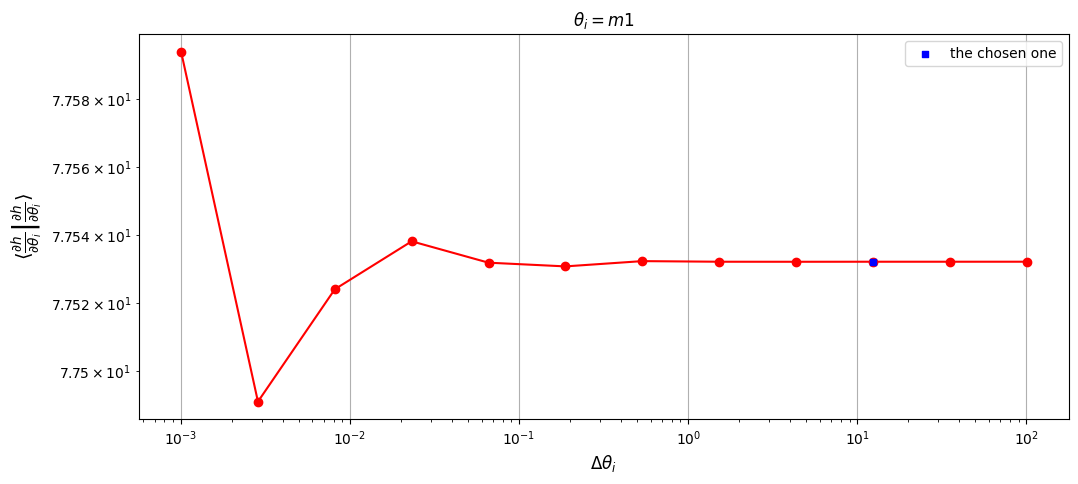

Gamma_ii for m2: 337056.3917987618
Gamma_ii for m2: 337056.39675132866
Gamma_ii for m2: 337056.2793384914
Gamma_ii for m2: 337056.6026889973
Gamma_ii for m2: 337055.4357005982
Gamma_ii for m2: 337056.8369042747
Gamma_ii for m2: 337059.40777998156
Gamma_ii for m2: 337052.7289283373
Gamma_ii for m2: 337138.4146303964
Gamma_ii for m2: 336939.0892004572
Gamma_ii for m2: 336493.1131662359
Gamma_ii for m2: 337879.6229504151
[np.float64(1.4693585170170814e-08), np.float64(3.483478708981814e-07), np.float64(9.593359196162055e-07), np.float64(3.4623040470684392e-06), np.float64(4.157173280933321e-06), np.float64(7.627366711947056e-06), np.float64(1.9815450435637146e-05), np.float64(0.0002541558551049836), np.float64(0.0005915770426405271), np.float64(0.0013253645223965532), np.float64(0.004103561416554233)]
0


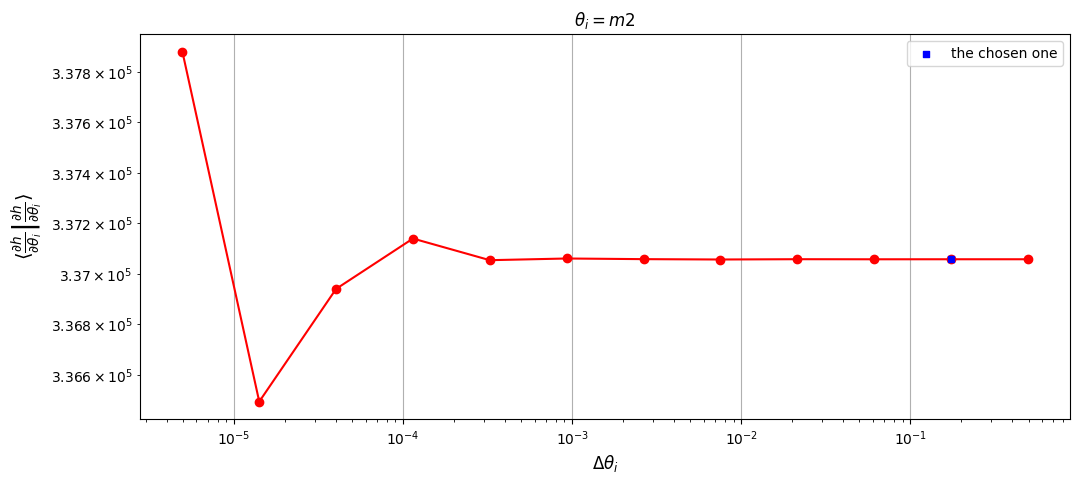

Gamma_ii for a: 149600646018.81924
Gamma_ii for a: 149600747096.43793
Gamma_ii for a: 149601341935.61197
Gamma_ii for a: 149600364785.36285
Gamma_ii for a: 149601914917.58173
Gamma_ii for a: 149588913883.37677
Gamma_ii for a: 149583257618.85574
Gamma_ii for a: 149648750071.55417
Gamma_ii for a: 149642898910.922
Gamma_ii for a: 150075042374.47223
Gamma_ii for a: 149211742688.68106
Gamma_ii for a: 173732448633.7168
[np.float64(6.756491571375852e-07), np.float64(3.976162020643941e-06), np.float64(6.5317370750863055e-06), np.float64(1.0361713750295676e-05), np.float64(8.691174945686138e-05), np.float64(3.781348669006129e-05), np.float64(0.0004376411608323507), np.float64(3.910082385970519e-05), np.float64(0.0028795158522889716), np.float64(0.005785735560989843), np.float64(0.14114062247941475)]
0


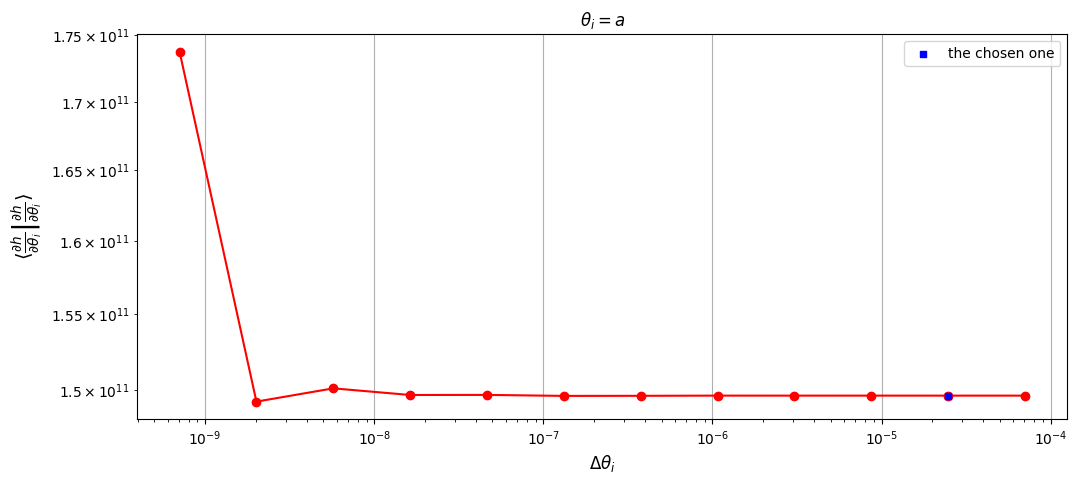

Gamma_ii for p0: 413238516368.8033
Gamma_ii for p0: 413238524630.38464
Gamma_ii for p0: 413238498570.02625
Gamma_ii for p0: 413238563802.32965
Gamma_ii for p0: 413238605807.48865
Gamma_ii for p0: 413238384647.31836
Gamma_ii for p0: 413240316422.0468
Gamma_ii for p0: 413239995931.3663
Gamma_ii for p0: 413246794128.326
Gamma_ii for p0: 413224761177.0588
Gamma_ii for p0: 413357031484.45526
Gamma_ii for p0: 413274324815.9819
[np.float64(1.99922825860748e-08), np.float64(6.306372346385192e-08), np.float64(1.5785628235065986e-07), np.float64(1.0164868046271204e-07), np.float64(5.351878685636546e-07), np.float64(4.674700535466746e-06), np.float64(7.755558118706919e-07), np.float64(1.645069497527849e-05), np.float64(5.331953294485957e-05), np.float64(0.00031999046180845853), np.float64(0.0002001253489681832)]
0


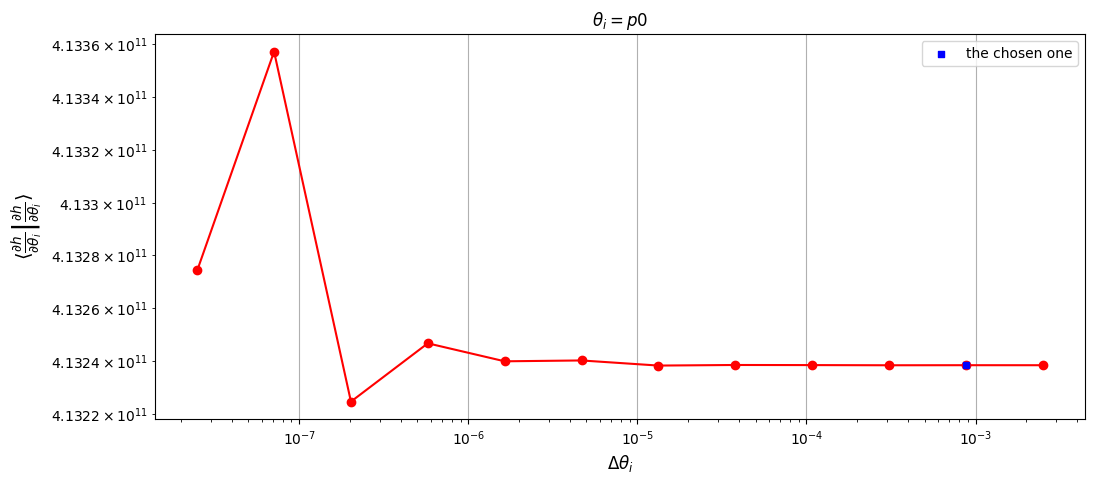

Gamma_ii for e0: 3474636279729.575
Gamma_ii for e0: 3474633421590.3276
Gamma_ii for e0: 3474634928810.251
Gamma_ii for e0: 3474608144547.699
Gamma_ii for e0: 3474655303094.1914
Gamma_ii for e0: 3474647933813.725
Gamma_ii for e0: 3474862065907.914
Gamma_ii for e0: 3478556247226.7944
Gamma_ii for e0: 3473714622207.197
Gamma_ii for e0: 3478172667604.9224
Gamma_ii for e0: 3502752138484.5337
Gamma_ii for e0: 3504903663812.044
[np.float64(8.225728877754343e-07), np.float64(4.3377792321218926e-07), np.float64(7.708570704235312e-06), np.float64(1.3572151013135797e-05), np.float64(2.120871123256558e-06), np.float64(6.162319255484355e-05), np.float64(0.0010619869441023065), np.float64(0.0013937889395535), np.float64(0.001281720553797407), np.float64(0.0070171881731390905), np.float64(0.0006138614734905972)]
1


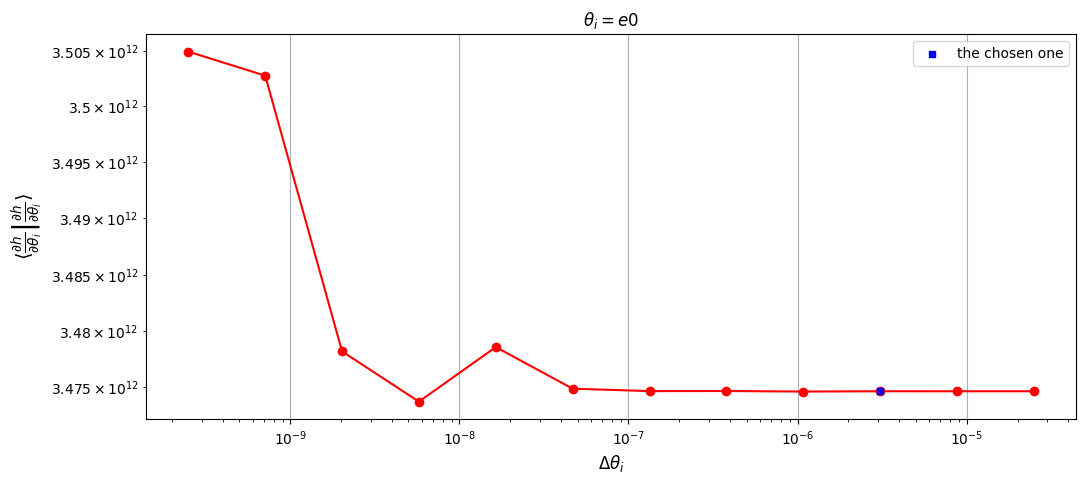

Gamma_ii for qS: 193128.1351066425
Gamma_ii for qS: 223468.08618511655
Gamma_ii for qS: 222963.454334651
Gamma_ii for qS: 222984.94333378598
Gamma_ii for qS: 223371.94987802126
Gamma_ii for qS: 223039.68670491787
Gamma_ii for qS: 222927.03634184497
Gamma_ii for qS: 223279.6734546914
Gamma_ii for qS: 225930.5438105276
Gamma_ii for qS: 245993.28408309817
Gamma_ii for qS: 401280.259880987
Gamma_ii for qS: 401852.71380247554
[np.float64(0.1357686083790105), np.float64(0.0022632940091972943), np.float64(9.636973157784238e-05), np.float64(0.0017325655457035452), np.float64(0.001489704267487498), np.float64(0.000505323916387405), np.float64(0.0015793516149063234), np.float64(0.011733120768563749), np.float64(0.08155808134092493), np.float64(0.3869788557352518), np.float64(0.0014245366569054087)]
2


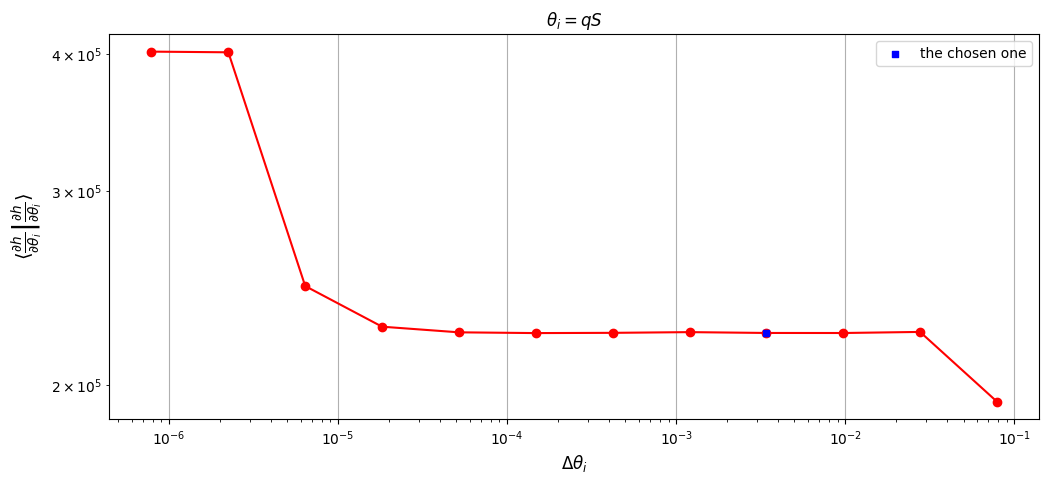

Gamma_ii for phiS: 310692.49321136734
Gamma_ii for phiS: 320352.12648594525
Gamma_ii for phiS: 320426.21858508483
Gamma_ii for phiS: 320427.07740493974
Gamma_ii for phiS: 320432.12466809974
Gamma_ii for phiS: 320425.5918683366
Gamma_ii for phiS: 320474.1944672687
Gamma_ii for phiS: 320596.22503001656
Gamma_ii for phiS: 322525.9711775692
Gamma_ii for phiS: 348245.8900191655
Gamma_ii for phiS: 569360.5212021907
Gamma_ii for phiS: 762221.195288784
[np.float64(0.030153173573523016), np.float64(0.0002312298271556987), np.float64(2.6802349597505555e-06), np.float64(1.5751426812235493e-05), np.float64(2.0387883892319298e-05), np.float64(0.00015165838551493737), np.float64(0.00038063630579688375), np.float64(0.005983227150691021), np.float64(0.07385562781568179), np.float64(0.38835609942914034), np.float64(0.2530245488824591)]
2


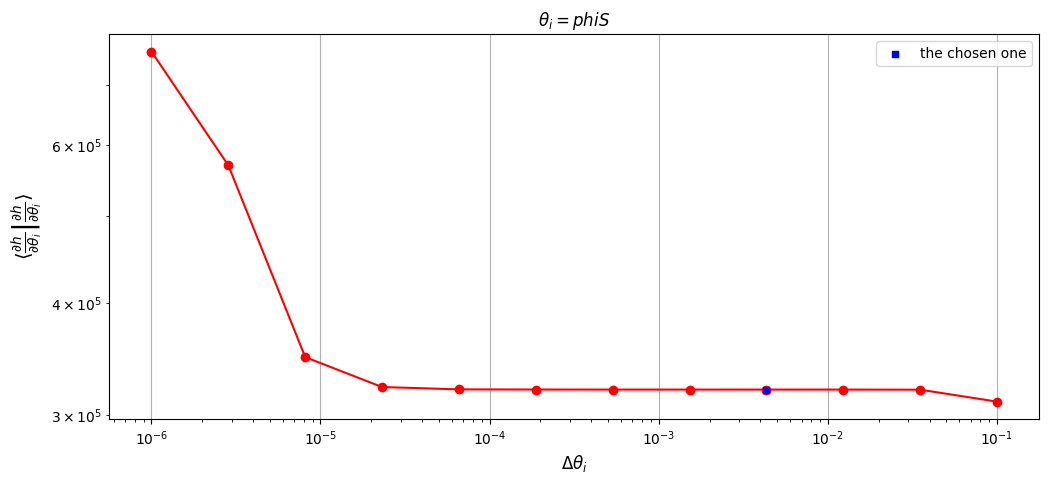

Gamma_ii for dev_1: 186182159.60967025
Gamma_ii for dev_1: 186182161.57007238
Gamma_ii for dev_1: 186182168.71605712
Gamma_ii for dev_1: 186182168.50002173
Gamma_ii for dev_1: 186182204.15837023
Gamma_ii for dev_1: 186182219.86205512
Gamma_ii for dev_1: 186181973.50888282
Gamma_ii for dev_1: 186182363.78444874
Gamma_ii for dev_1: 186174720.22115847
Gamma_ii for dev_1: 186178730.99918854
Gamma_ii for dev_1: 186191579.13473663
Gamma_ii for dev_1: 186317677.49968606
[np.float64(1.0529484213463713e-08), np.float64(3.8381681706390346e-08), np.float64(1.160344181191803e-09), np.float64(1.9152393571620258e-07), np.float64(8.434578182527723e-08), np.float64(1.323184880143579e-06), np.float64(2.0962005100230595e-06), np.float64(4.1055860221991105e-05), np.float64(2.1542622019940416e-05), np.float64(6.900492282085155e-05), np.float64(0.0006767922756532185)]
2


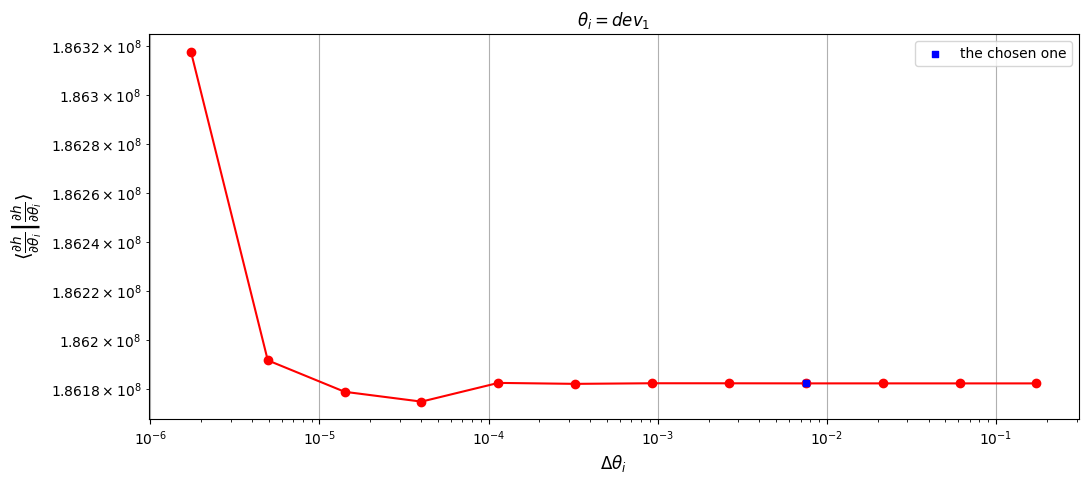

Gamma_ii for dev_2: 217252.54309523376
Gamma_ii for dev_2: 217252.5733247271
Gamma_ii for dev_2: 217252.5260728622
Gamma_ii for dev_2: 217252.29755138743
Gamma_ii for dev_2: 217254.62735166142
Gamma_ii for dev_2: 217245.28390655614
Gamma_ii for dev_2: 217252.10306013768
Gamma_ii for dev_2: 217258.9591220251
Gamma_ii for dev_2: 217213.53622343604
Gamma_ii for dev_2: 217348.85632940385
Gamma_ii for dev_2: 218216.04647548424
Gamma_ii for dev_2: 217542.16013984135
[np.float64(1.3914446615171317e-07), np.float64(2.1749742451121817e-07), np.float64(1.0518713834478889e-06), np.float64(1.0723823480266331e-05), np.float64(4.300873619559605e-05), np.float64(3.138820515654378e-05), np.float64(3.155709626479766e-05), np.float64(0.00020911633491536735), np.float64(0.0006225940557180826), np.float64(0.003973998063326743), np.float64(0.0030977275173221666)]
0


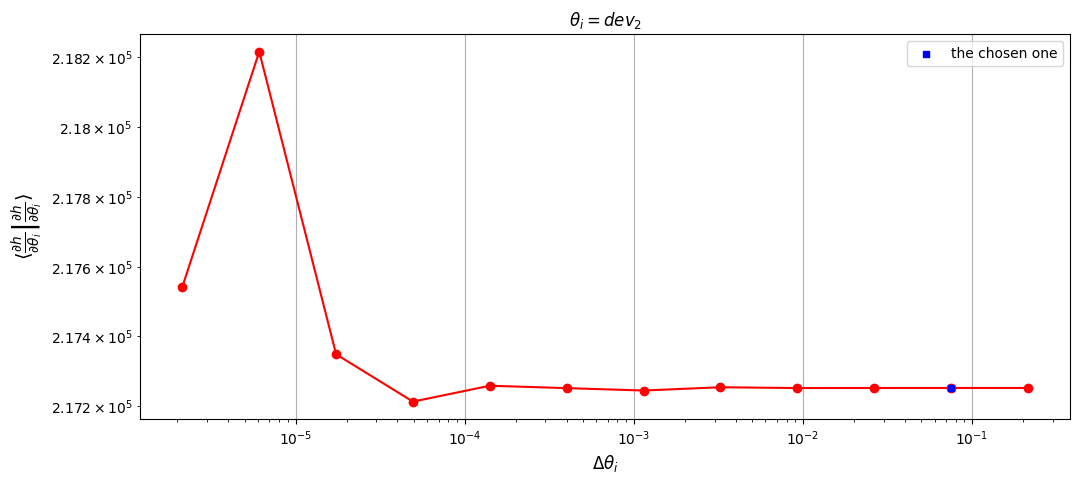

stable deltas: {'m1': 12.362660507164726, 'm2': 0.17387407692848514, 'a': 2.4768434803441604e-05, 'p0': 0.0008761579990472084, 'e0': 3.077618626748496e-06, 'qS': 0.003409287231303818, 'phiS': 0.0043370661825470214, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev_1': 0.007516487351340469, 'dev_2': 0.07508616842082162}
Time taken to compute stable deltas is 28.668500185012817 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 2.2349352836608887 seconds


In [7]:
x_best_fit_0PA_dev = [1002773.5087947377, 4951.996076834916, 0.7054139072521527, 24.953294077033906, 0.24963513535683254, 0.7875895689149237, 1.001918539952816, 0.9156601963955119, 0.4109580708321073, 1.7364060670631016, 2.1384810088591153]
add_kwargs_0PA_dev = {'chi2': 0.95, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': x_best_fit_0PA_dev[9], 'dev_2': x_best_fit_0PA_dev[10]}


m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev
wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs_0PA_dev['chi2'],add_kwargs_0PA_dev['evolve_1PA'],
                    add_kwargs_0PA_dev['evolve_primary'],add_kwargs_0PA_dev['evolve_2PA'],
                      add_kwargs_0PA_dev['deviation_included'],add_kwargs_0PA_dev['dev_1'],add_kwargs_0PA_dev['dev_2']]


param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0','dev_1','dev_2']  
dim = len(param_names_to_infer)
param_names = param_names_to_infer
SNR = sef.SNRcalc_SEF(*wave_params,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

param_dict = {
    'm1': wave_params[0],
    'm2': wave_params[1],
    'a': wave_params[2],
    'p0': wave_params[3],
    'e0': wave_params[4],
    'xI0': wave_params[5],
    'dist': wave_params[6],
    'qS': wave_params[7],
    'phiS': wave_params[8],
    'qK': wave_params[9],
    'phiK': wave_params[10],
    'Phi_phi0': wave_params[11],
    'Phi_theta0': wave_params[12],
    'Phi_r0': wave_params[13]}

Fisher_0PA_dev = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_kwargs_0PA_dev,
            live_dangerously = False, stability_plot = True,der_order = 6, Ndelta = 12,return_derivatives = False)



In [9]:
np.save('1gen_results/Fisher_0PA_dev_simple_imri.npy', Fisher_0PA_dev)
np.save('1gen_results/Fisher_1PA_imri.npy',     Fisher_1PA)
np.save('1gen_results/Fisher_0PA_imri.npy',     Fisher_0PA)